In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from econml.dml import LinearDML, CausalForestDML
from econml.metalearners import XLearner, TLearner, SLearner
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
import networkx as nx
from IPython.display import display
import warnings
from econml.dml import CausalForestDML, LinearDML
from xgboost import XGBRegressor, XGBClassifier
import numpy as np
import shap
import numpy as np
import pandas as pd
from econml.metalearners import TLearner, XLearner
from sklearn.ensemble import GradientBoostingClassifier
warnings.filterwarnings('ignore')

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

train = pd.read_csv('/content/train_processed_v4.csv')
test = pd.read_csv('/content/test_processed_v4.csv')

# Data Processing for Causal Inference

In [6]:
print("Dataset dimensions:", train.shape)
print("Columns:", train.columns.tolist())

print("\nBasic dataset statistics:")
print(f"No-show rate: {train['No-show'].mean():.4f}")
print(f"SMS received rate: {train['SMS_received'].mean():.4f}")

Dataset dimensions: (88421, 98)
Columns: ['PatientId', 'AppointmentID', 'Age', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show', 'WaitTime_Log', 'Gender_Encoded', 'ScheduledDay_Month', 'ScheduledDay_Weekday', 'AppointmentDay_Month', 'AppointmentDay_Weekday', 'NB_ANDORINHAS', 'NB_ANTÔNIO HONÓRIO', 'NB_ARIOVALDO FAVALESSA', 'NB_BARRO VERMELHO', 'NB_BELA VISTA', 'NB_BENTO FERREIRA', 'NB_BOA VISTA', 'NB_BONFIM', 'NB_CARATOÍRA', 'NB_CENTRO', 'NB_COMDUSA', 'NB_CONQUISTA', 'NB_CONSOLAÇÃO', 'NB_CRUZAMENTO', 'NB_DA PENHA', 'NB_DE LOURDES', 'NB_DO CABRAL', 'NB_DO MOSCOSO', 'NB_DO QUADRO', 'NB_ENSEADA DO SUÁ', 'NB_ESTRELINHA', 'NB_FONTE GRANDE', 'NB_FORTE SÃO JOÃO', 'NB_FRADINHOS', 'NB_GOIABEIRAS', 'NB_GRANDE VITÓRIA', 'NB_GURIGICA', 'NB_HORTO', 'NB_ILHA DAS CAIEIRAS', 'NB_ILHA DE SANTA MARIA', 'NB_ILHA DO BOI', 'NB_ILHA DO FRADE', 'NB_ILHA DO PRÍNCIPE', 'NB_ILHAS OCEÂNICAS DE TRINDADE', 'NB_INHANGUETÁ', 'NB_ITARARÉ', 'NB_JABOUR', 'NB_JARDIM CAMBURI', 

In [7]:
# Create binary WaitTime indicator for easier causal analysis
median_wait = train['WaitTime_Log'].median()
train['HighWaitTime'] = (train['WaitTime_Log'] > median_wait).astype(int)

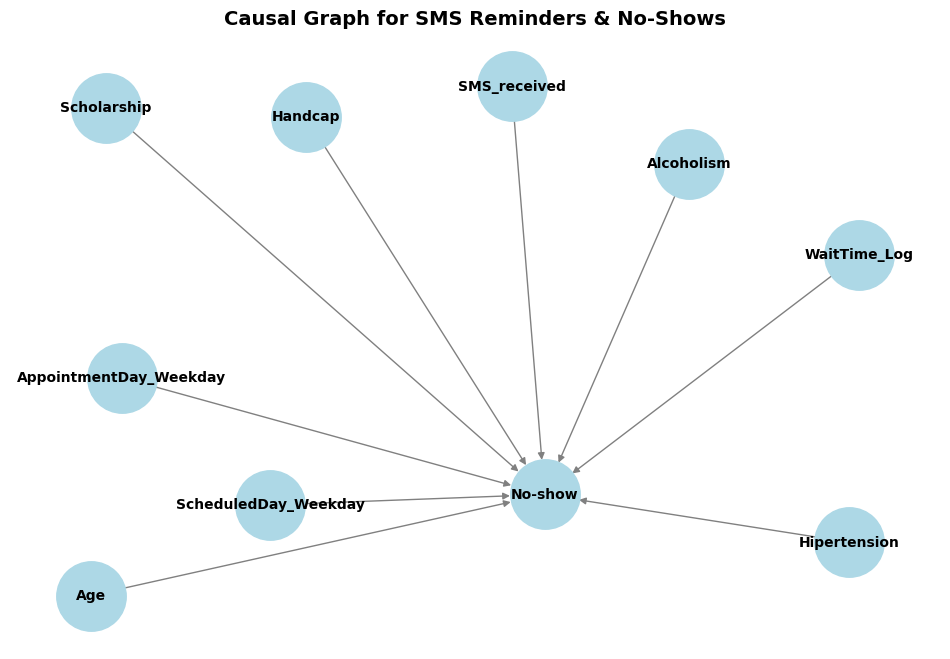

In [16]:
# =======================================================
# Visual Representation of Causal Relationships
# =======================================================

# Create a directed graph for SMS causal relationships
G_sms = nx.DiGraph()

# Define nodes representing key features in the dataset
nodes = [
    'SMS_received', 'WaitTime_Log', 'Age', 'Handcap', 'Alcoholism',
    'Scholarship', 'Hipertension', 'ScheduledDay_Weekday',
    'AppointmentDay_Weekday', 'No-show'
]

# Add nodes to the graph
G_sms.add_nodes_from(nodes)

# Define causal relationships (edges)
edges = [
    ('SMS_received', 'No-show'),  # SMS reminders potentially reduce no-shows
    ('WaitTime_Log', 'No-show'),  # Longer wait times may increase no-shows
    ('Age', 'No-show'),  # Age may influence appointment adherence
    ('Handcap', 'No-show'),  # Accessibility challenges may impact attendance
    ('Alcoholism', 'No-show'),  # Alcohol-related conditions may correlate with no-shows
    ('Scholarship', 'No-show'),  # Socioeconomic factors may influence attendance
    ('Hipertension', 'No-show'),  # Chronic conditions may impact appointment adherence
    ('ScheduledDay_Weekday', 'No-show'),  # Weekend scheduling may affect attendance
    ('AppointmentDay_Weekday', 'No-show')  # End-of-week appointments may influence behavior
]

# Add edges to the graph
G_sms.add_edges_from(edges)

# Visualize the causal graph
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G_sms, seed=42)  # Ensures consistent node placement
nx.draw_networkx(
    G_sms,
    pos=pos,
    arrows=True,
    with_labels=True,
    node_color='lightblue',
    node_size=2500,
    edge_color='gray',
    font_size=10,
    font_weight='bold'
)

# Add a title and remove axis for better visualization
plt.title("Causal Graph for SMS Reminders & No-Shows", fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

# Do SMS reminders causally reduce no-show rates?

In [9]:
# 1.1 Initial exploration
print("\n1.1 No-show rates by SMS status:")
sms_groups = train.groupby('SMS_received')['No-show'].agg(['mean', 'count'])
print(sms_groups)


1.1 No-show rates by SMS status:
                  mean  count
SMS_received                 
0             0.166916  60126
1             0.276798  28295


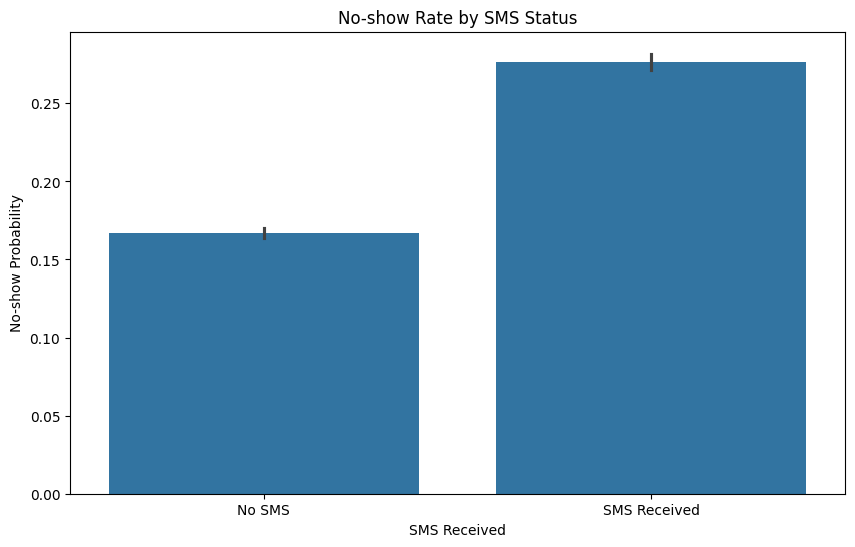

In [10]:
# 1.2 Visualization of no-show rates by SMS status
plt.figure(figsize=(10, 6))
sns.barplot(x='SMS_received', y='No-show', data=train, errorbar=('ci', 95))
plt.title('No-show Rate by SMS Status')
plt.xlabel('SMS Received')
plt.ylabel('No-show Probability')
plt.xticks([0, 1], ['No SMS', 'SMS Received'])
plt.show()

In [14]:
# Define core features and treatment columns
core_features = ['WaitTime_Log', 'Age', 'Handcap', 'Alcoholism','Scholarship',
                 'Hipertension', 'ScheduledDay_Weekday', 'AppointmentDay_Weekday']
treatment_cols = ['SMS_received']

features = [f for f in core_features if f in train.columns]
print(f"\nUsing features for causal analysis: {features}")


Using features for causal analysis: ['WaitTime_Log', 'Age', 'Handcap', 'Alcoholism', 'Scholarship', 'Hipertension', 'ScheduledDay_Weekday', 'AppointmentDay_Weekday']


## SMOTE for imbalanced data

In [20]:
# ====================================================
# SMOTE for Addressing Class Imbalance
# ====================================================

# Define features for SMOTE

features_smote = core_features + treatment_cols

df_smote = train[features_smote + ['No-show']].copy()

# Identify categorical variables
categorical_cols = ['ScheduledDay_Weekday', 'AppointmentDay_Weekday']

# Convert categorical variables into numeric format
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_smote[col] = le.fit_transform(df_smote[col])
    label_encoders[col] = le  # Store encoders if needed later for inverse transformation

# Apply SMOTE
smote = SMOTE(random_state=42)
X_sm, Y_sm = smote.fit_resample(df_smote.drop('No-show', axis=1), df_smote['No-show'])

# Print distribution before and after SMOTE
print("\nBefore SMOTE, distribution of No-show outcome:")
print(train['No-show'].value_counts())
print("\nAfter SMOTE, distribution of No-show outcome:")
print(pd.Series(Y_sm).value_counts())

# Update variables for causal ML analyses
X_resampled = X_sm.drop(treatment_cols, axis=1)
T_sms_resampled = X_sm['SMS_received'].values
Y_resampled = Y_sm

# Create a resampled dataframe for visualization
df_resampled = pd.DataFrame(X_resampled, columns=[col for col in core_features if col not in categorical_cols])
df_resampled[categorical_cols] = X_sm[categorical_cols].apply(lambda col: label_encoders[col.name].inverse_transform(col))  # Restore categorical labels
df_resampled['SMS_received'] = T_sms_resampled
df_resampled['No-show'] = Y_resampled

# Print selected features for analysis
features = [f for f in core_features if f in train.columns]
print(f"\nUsing features for causal analysis: {features}")


Before SMOTE, distribution of No-show outcome:
No-show
0    70553
1    17868
Name: count, dtype: int64

After SMOTE, distribution of No-show outcome:
No-show
0    70553
1    70553
Name: count, dtype: int64

Using features for causal analysis: ['WaitTime_Log', 'Age', 'Handcap', 'Alcoholism', 'Scholarship', 'Hipertension', 'ScheduledDay_Weekday', 'AppointmentDay_Weekday']


## DML

In [21]:
# Convert data types for DML
X_dml = X_resampled.copy()
Y_dml = Y_resampled.astype(float)  # DML requires float outcome
T_sms_dml = T_sms_resampled.astype(float)  # DML requires float treatment

# LinearDML implementation
print("\n--- Linear DML Implementation ---")
linear_dml = LinearDML(
    model_y=XGBRegressor(n_estimators=100, random_state=42, objective="reg:squarederror"),
    model_t=XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric="logloss"),
    discrete_treatment=True,
    cv=5
)

# Fit the Linear DML model
linear_dml.fit(Y_dml, T_sms_dml, X=X_dml)

# Get ATE and confidence intervals
ate_dml = linear_dml.ate(X_dml)  # Returns a scalar, not an array
lower, upper = linear_dml.ate_interval(X_dml)

print(f"Linear DML ATE (SMS effect): {ate_dml:.4f}")
print(f"95% CI: [{lower:.4f}, {upper:.4f}]")

# Get individual treatment effects (CATE)
cate_dml = linear_dml.effect(X_dml)
df_resampled['CATE_DML'] = cate_dml

# CausalForestDML for heterogeneous treatment effects
print("\n--- Causal Forest DML Implementation ---")
forest_dml = CausalForestDML(
    model_y=XGBRegressor(n_estimators=100, random_state=42, objective="reg:squarederror"),
    model_t=XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric="logloss"),
    discrete_treatment=True,
    n_estimators=100,
    random_state=42
)

# Fit the Causal Forest DML model
forest_dml.fit(Y_dml, T_sms_dml, X=X_dml)

# Get ATE for Causal Forest
ate_forest = forest_dml.ate(X_dml)

print(f"Causal Forest DML ATE (SMS effect): {ate_forest:.4f}")



--- Linear DML Implementation ---
Linear DML ATE (SMS effect): -0.0944
95% CI: [-0.1042, -0.0846]

--- Causal Forest DML Implementation ---
Causal Forest DML ATE (SMS effect): -0.0963


## Meta-Learners

In [22]:
# ====================================================
# META-LEARNERS: T-LEARNER and X-LEARNER with classifiers
# ====================================================

# --- T-Learner using GradientBoostingClassifier for binary outcome ---
t_learner = TLearner(models=GradientBoostingClassifier(n_estimators=100, random_state=42))
t_learner.fit(Y_resampled, T_sms_resampled, X=X_resampled)
cate_t = t_learner.effect(X_resampled)
print(f"\nT-Learner ATE (SMS effect): {np.mean(cate_t):.4f}")

# --- X-Learner using GradientBoostingClassifier for binary outcome ---
x_learner = XLearner(
    models=GradientBoostingClassifier(n_estimators=100, random_state=42),
    propensity_model=LogisticRegression(max_iter=1000, random_state=42)
)
x_learner.fit(Y_resampled, T_sms_resampled, X=X_resampled)
cate_x = x_learner.effect(X_resampled)
print(f"X-Learner ATE (SMS effect): {np.mean(cate_x):.4f}")

# --- S-Learner for reference ---
s_learner = SLearner(overall_model=GradientBoostingClassifier(n_estimators=100, random_state=42))
s_learner.fit(Y_resampled, T_sms_resampled, X=X_resampled)
cate_s = s_learner.effect(X_resampled)
print(f"S-Learner ATE (SMS effect): {np.mean(cate_s):.4f}")

# Create a DataFrame for CATE analysis
df_resampled['CATE_T'] = cate_t
df_resampled['CATE_X'] = cate_x
df_resampled['CATE_S'] = cate_s


T-Learner ATE (SMS effect): -0.1922
X-Learner ATE (SMS effect): -0.3267
S-Learner ATE (SMS effect): -0.1471


# Placebo Test

In [25]:
df_placebo = df_resampled.copy()

# One-hot encode weekday columns if they exist
if 'ScheduledDay_Weekday' in df_placebo.columns and df_placebo['ScheduledDay_Weekday'].dtype == object:
    df_placebo = pd.get_dummies(df_placebo, columns=['ScheduledDay_Weekday'], drop_first=True)

if 'AppointmentDay_Weekday' in df_placebo.columns and df_placebo['AppointmentDay_Weekday'].dtype == object:
    df_placebo = pd.get_dummies(df_placebo, columns=['AppointmentDay_Weekday'], drop_first=True)

# Shuffle treatment labels (create placebo scenario)
df_placebo['SMS_received'] = np.random.permutation(df_placebo['SMS_received'].values)

# Define updated core_features (excluding original string columns)
core_features_numeric = [col for col in df_placebo.columns if col not in ['No-show', 'SMS_received']]

# Fit T-Learner with placebo treatment
t_learner_placebo = TLearner(models=GradientBoostingClassifier(n_estimators=100, random_state=42))
t_learner_placebo.fit(df_placebo['No-show'], df_placebo['SMS_received'], X=df_placebo[core_features_numeric])
cate_t_placebo = t_learner_placebo.effect(df_placebo[core_features_numeric])

# Fit X-Learner with placebo treatment
x_learner_placebo = XLearner(models=GradientBoostingClassifier(n_estimators=100, random_state=42))
x_learner_placebo.fit(df_placebo['No-show'], df_placebo['SMS_received'], X=df_placebo[core_features_numeric])
cate_x_placebo = x_learner_placebo.effect(df_placebo[core_features_numeric])

# Fit S-Learner with placebo treatment
s_learner_placebo = SLearner(overall_model=GradientBoostingClassifier(n_estimators=100, random_state=42))
s_learner_placebo.fit(df_placebo['No-show'], df_placebo['SMS_received'], X=df_placebo[core_features_numeric])
cate_s_placebo = s_learner_placebo.effect(df_placebo[core_features_numeric])

# Print Placebo ATE results
print(f"Placebo T-Learner ATE: {np.mean(cate_t_placebo):.4f}")
print(f"Placebo X-Learner ATE: {np.mean(cate_x_placebo):.4f}")
print(f"Placebo S-Learner ATE: {np.mean(cate_s_placebo):.4f}")

Placebo T-Learner ATE: 0.0081
Placebo X-Learner ATE: 0.0078
Placebo S-Learner ATE: 0.0000


## Conditinoal Average Treatment Effect (CATE) by age groups

In [26]:
# Create age groups for analysis
age_bins = [0, 18, 40, 65, 100]
age_labels = ['Children', 'Young Adults', 'Adults', 'Elderly']
df_resampled['AgeGroup'] = pd.cut(df_resampled['Age'], bins=age_bins, labels=age_labels)

# Get average CATE by age group
print("\nCausal effect of SMS by age group (T-Learner):")
cate_by_age_t = df_resampled.groupby('AgeGroup')['CATE_T'].mean()
print(cate_by_age_t)

print("\nCausal effect of SMS by age group (X-Learner):")
cate_by_age_x = df_resampled.groupby('AgeGroup')['CATE_X'].mean()
print(cate_by_age_x)


Causal effect of SMS by age group (T-Learner):
AgeGroup
Children       -0.091615
Young Adults   -0.086980
Adults         -0.292186
Elderly        -0.410061
Name: CATE_T, dtype: float64

Causal effect of SMS by age group (X-Learner):
AgeGroup
Children       -0.364534
Young Adults   -0.303765
Adults         -0.317334
Elderly        -0.271097
Name: CATE_X, dtype: float64


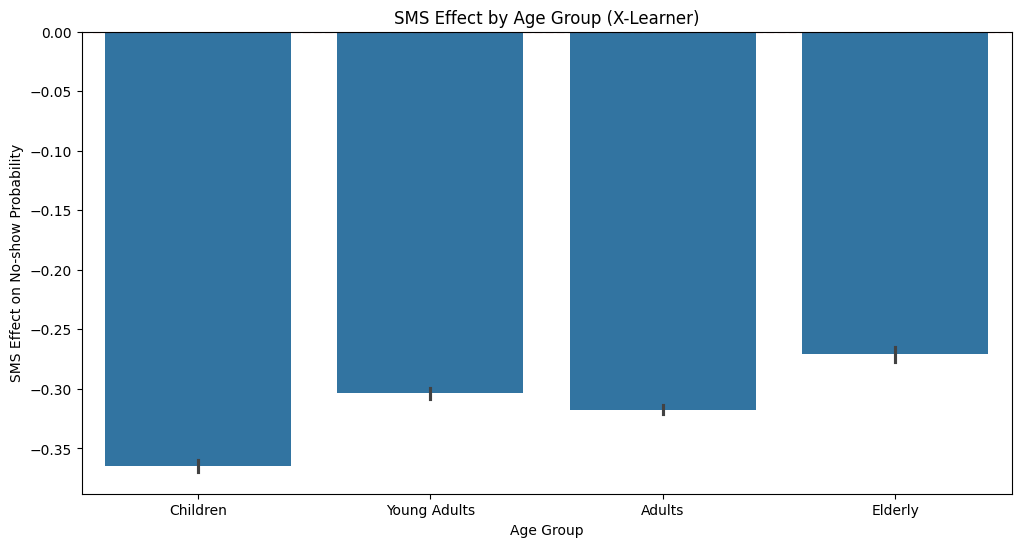

In [47]:
# Plot CATE by Age Group
plt.figure(figsize=(12, 6))
sns.barplot(x='AgeGroup', y='CATE_X', data=df_resampled, estimator=np.mean, errorbar=('ci', 95))
plt.title('SMS Effect by Age Group (X-Learner)')
plt.xlabel('Age Group')
plt.ylabel('SMS Effect on No-show Probability')
plt.axhline(y=0, color='r', linestyle='--')

## Conditinoal Average Treatment Effect (CATE) by sponsorship groups

In [30]:
# CATE by scholarship status
print("\nCausal effect of SMS by scholarship status (T-Learner):")
cate_by_scholarship_t = df_resampled.groupby('Scholarship')['CATE_T'].mean()
print(cate_by_scholarship_t)

print("\nCausal effect of SMS by scholarship status (X-Learner):")
cate_by_scholarship_x = df_resampled.groupby('Scholarship')['CATE_X'].mean()
print(cate_by_scholarship_x)


Causal effect of SMS by scholarship status (T-Learner):
Scholarship
0   -0.195365
1   -0.156474
Name: CATE_T, dtype: float64

Causal effect of SMS by scholarship status (X-Learner):
Scholarship
0   -0.326352
1   -0.330070
Name: CATE_X, dtype: float64


([<matplotlib.axis.XTick at 0x7c73f1424f10>,
 [Text(0, 0, 'No Scholarship'), Text(1, 0, 'Scholarship')])

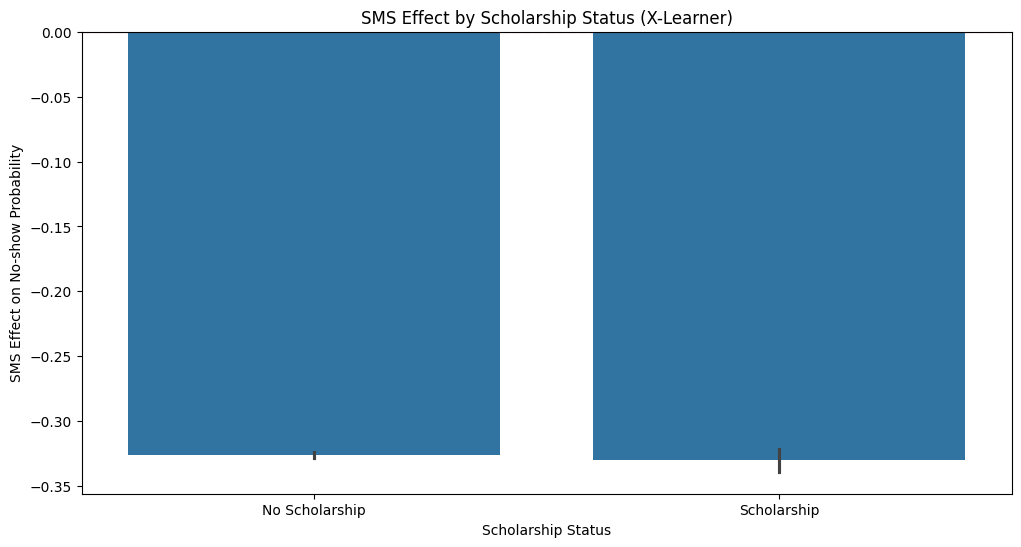

In [48]:
# Plot CATE by scholarship status
plt.figure(figsize=(12, 6))
sns.barplot(x='Scholarship', y='CATE_X', data=df_resampled, estimator=np.mean, errorbar=('ci', 95))
plt.title('SMS Effect by Scholarship Status (X-Learner)')
plt.xlabel('Scholarship Status')
plt.ylabel('SMS Effect on No-show Probability')
plt.axhline(y=0, color='r', linestyle='--')
plt.xticks([0, 1], ['No Scholarship', 'Scholarship'])

## Conditinoal Average Treatment Effect (CATE) by wait time groups

In [33]:
# Compute Median Wait Time
median_wait = df_resampled['WaitTime_Log'].median()
df_resampled['HighWaitTime'] = (df_resampled['WaitTime_Log'] > median_wait).astype(int)

# CATE by High Wait Time
print("\nCausal effect of SMS by High Wait Time (T-Learner):")
cate_by_high_wait_t = df_resampled.groupby('HighWaitTime')['CATE_T'].mean()
print(cate_by_high_wait_t)

print("\nCausal effect of SMS by High Wait Time (X-Learner):")
cate_by_high_wait_x = df_resampled.groupby('HighWaitTime')['CATE_X'].mean()
print(cate_by_high_wait_x)


Causal effect of SMS by High Wait Time (T-Learner):
HighWaitTime
0   -0.226888
1   -0.156237
Name: CATE_T, dtype: float64

Causal effect of SMS by High Wait Time (X-Learner):
HighWaitTime
0   -0.561954
1   -0.082567
Name: CATE_X, dtype: float64


([<matplotlib.axis.XTick at 0x7c73e66d4810>,
 [Text(0, 0, 'Low Wait Time'), Text(1, 0, 'High Wait Time')])

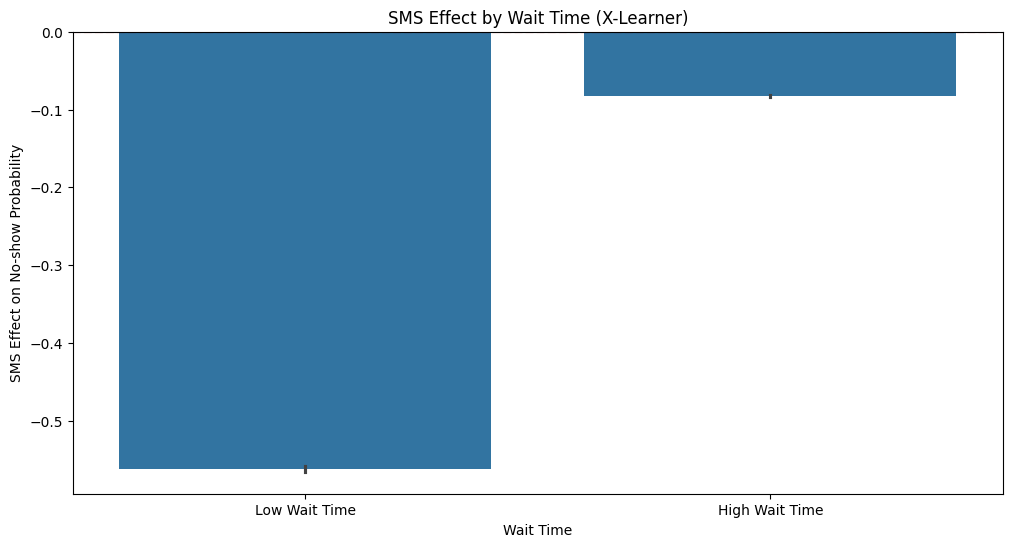

In [49]:
plt.figure(figsize=(12, 6))
sns.barplot(x='HighWaitTime', y='CATE_X', data=df_resampled, estimator=np.mean, errorbar=('ci', 95))
plt.title('SMS Effect by Wait Time (X-Learner)')
plt.xlabel('Wait Time')
plt.ylabel('SMS Effect on No-show Probability')
plt.axhline(y=0, color='r', linestyle='--')
plt.xticks([0, 1], ['Low Wait Time', 'High Wait Time'])

## Conditinoal Average Treatment Effect (CATE) by Scheduled Weekday

In [36]:
# Compute CATE by Scheduled Weekday
print("\nCausal effect of SMS by Scheduled Weekday (T-Learner):")
cate_by_sched_weekday_t = df_resampled.groupby('ScheduledDay_Weekday')['CATE_T'].mean()
print(cate_by_sched_weekday_t)

print("\nCausal effect of SMS by Scheduled Weekday (X-Learner):")
cate_by_sched_weekday_x = df_resampled.groupby('ScheduledDay_Weekday')['CATE_X'].mean()
print(cate_by_sched_weekday_x)


Causal effect of SMS by Scheduled Weekday (T-Learner):
ScheduledDay_Weekday
Friday      -0.185739
Monday      -0.235300
Saturday    -0.233333
Thursday    -0.157192
Tuesday     -0.190114
Wednesday   -0.187141
Name: CATE_T, dtype: float64

Causal effect of SMS by Scheduled Weekday (X-Learner):
ScheduledDay_Weekday
Friday      -0.297494
Monday      -0.394143
Saturday    -0.291350
Thursday    -0.249742
Tuesday     -0.337361
Wednesday   -0.336634
Name: CATE_X, dtype: float64


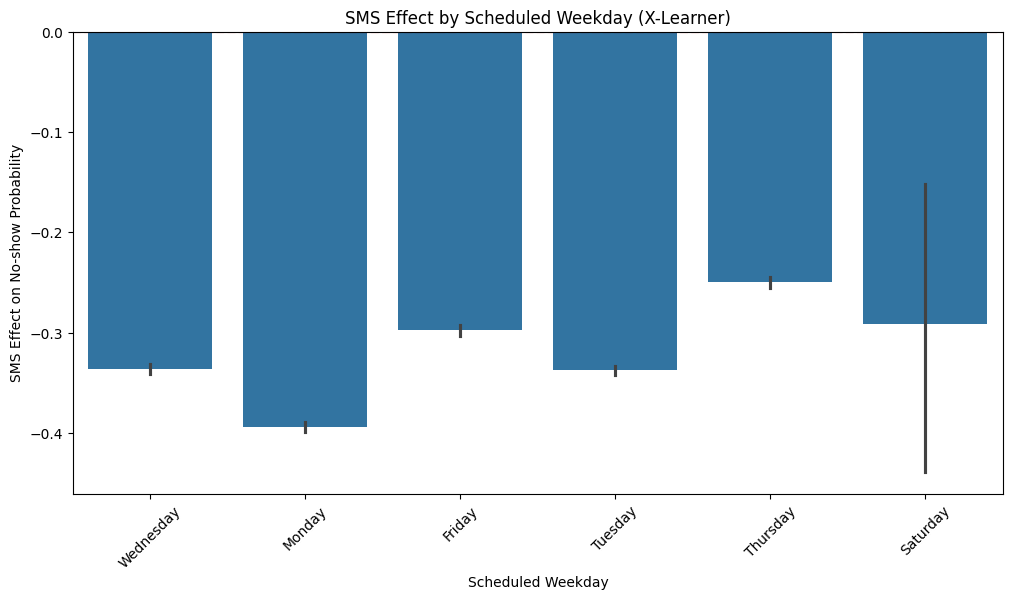

In [50]:
# Visualization: SMS Effect by Scheduled Weekday
plt.figure(figsize=(12, 6))
sns.barplot(x='ScheduledDay_Weekday', y='CATE_X', data=df_resampled, estimator=np.mean, errorbar=('ci', 95))
plt.title('SMS Effect by Scheduled Weekday (X-Learner)')
plt.xlabel('Scheduled Weekday')
plt.ylabel('SMS Effect on No-show Probability')
plt.axhline(y=0, color='r', linestyle='--')
plt.xticks(rotation=45)
plt.show()

## Conditinoal Average Treatment Effect (CATE) by Appointment Weekday

In [38]:
print("\nCausal effect of SMS by Appointment Weekday (T-Learner):")
cate_by_appt_weekday_t = df_resampled.groupby('AppointmentDay_Weekday')['CATE_T'].mean()
print(cate_by_appt_weekday_t)

print("\nCausal effect of SMS by Appointment Weekday (X-Learner):")
cate_by_appt_weekday_x = df_resampled.groupby('AppointmentDay_Weekday')['CATE_X'].mean()
print(cate_by_appt_weekday_x)


Causal effect of SMS by Appointment Weekday (T-Learner):
AppointmentDay_Weekday
Friday      -0.237892
Monday      -0.192727
Saturday    -0.381818
Thursday    -0.203730
Tuesday     -0.118000
Wednesday   -0.223884
Name: CATE_T, dtype: float64

Causal effect of SMS by Appointment Weekday (X-Learner):
AppointmentDay_Weekday
Friday      -0.439874
Monday      -0.299295
Saturday    -0.240489
Thursday    -0.345743
Tuesday     -0.209657
Wednesday   -0.368934
Name: CATE_X, dtype: float64


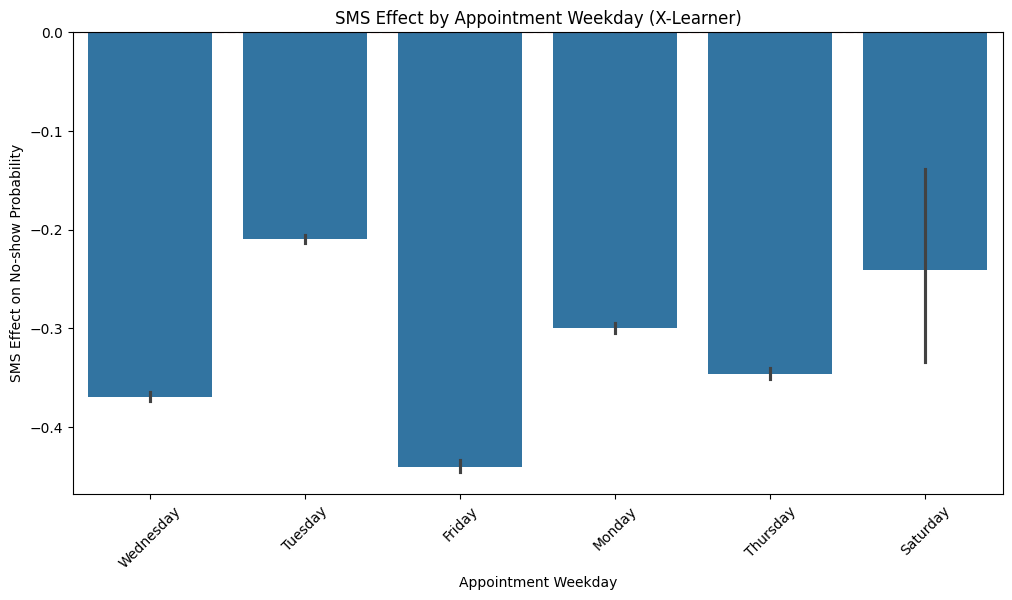

In [51]:
# Visualization: SMS Effect by Appointment Weekday
plt.figure(figsize=(12, 6))
sns.barplot(x='AppointmentDay_Weekday', y='CATE_X', data=df_resampled, estimator=np.mean, errorbar=('ci', 95))
plt.title('SMS Effect by Appointment Weekday (X-Learner)')
plt.xlabel('Appointment Weekday')
plt.ylabel('SMS Effect on No-show Probability')
plt.axhline(y=0, color='r', linestyle='--')
plt.xticks(rotation=45)
plt.show()

# SHAP Analysis

## X-Learner

In [52]:
# Get treatment and control models
control_model = x_learner.models[0]  # Model trained on control group (T=0)
treatment_model = x_learner.models[1]  # Model trained on treatment group (T=1)

# Convert X_resampled to numpy array for SHAP analysis
X_resampled_array = X_resampled.values
X_resampled_columns = X_resampled.columns

# Create SHAP explainers
explainer_control = shap.TreeExplainer(control_model)
explainer_treatment = shap.TreeExplainer(treatment_model)

# Compute SHAP values for control and treatment groups
shap_values_control = explainer_control.shap_values(X_resampled_array)
shap_values_treatment = explainer_treatment.shap_values(X_resampled_array)

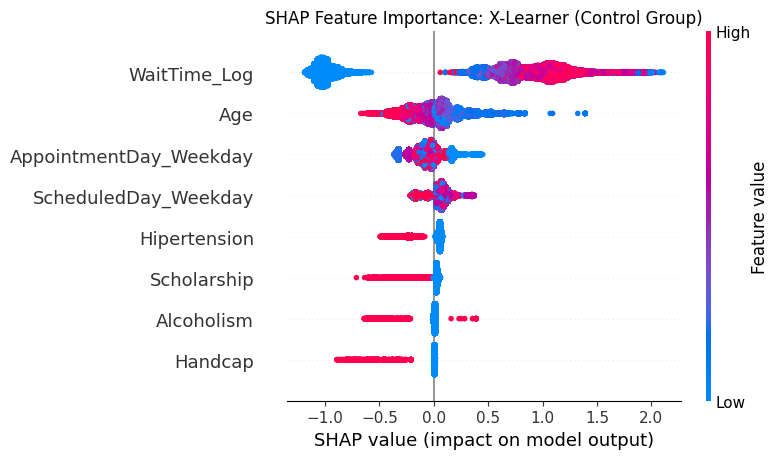

In [53]:
# Create a function to plot SHAP summary plots
def plot_shap_summary(shap_values, X, columns, title):
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X, feature_names=columns, show=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Plot SHAP summary for control group
plot_shap_summary(
    shap_values_control,
    X_resampled_array,
    X_resampled_columns,
    "SHAP Feature Importance: X-Learner (Control Group)"
)

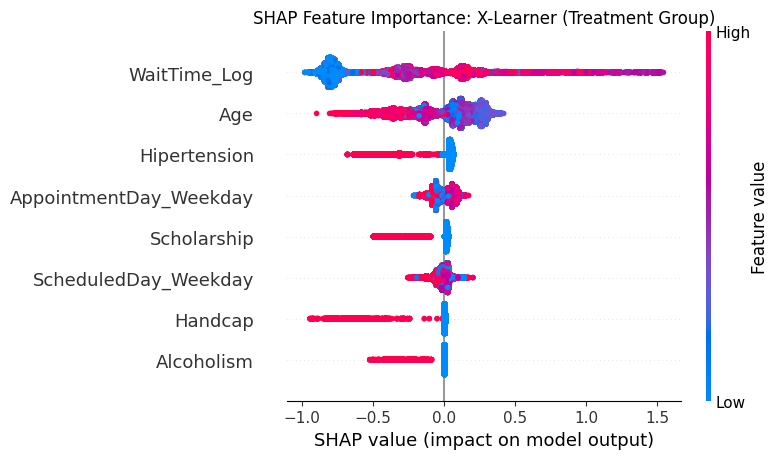

In [54]:
# Plot SHAP summary for treatment group
plot_shap_summary(
    shap_values_treatment,
    X_resampled_array,
    X_resampled_columns,
    "SHAP Feature Importance: X-Learner (Treatment Group)"
)

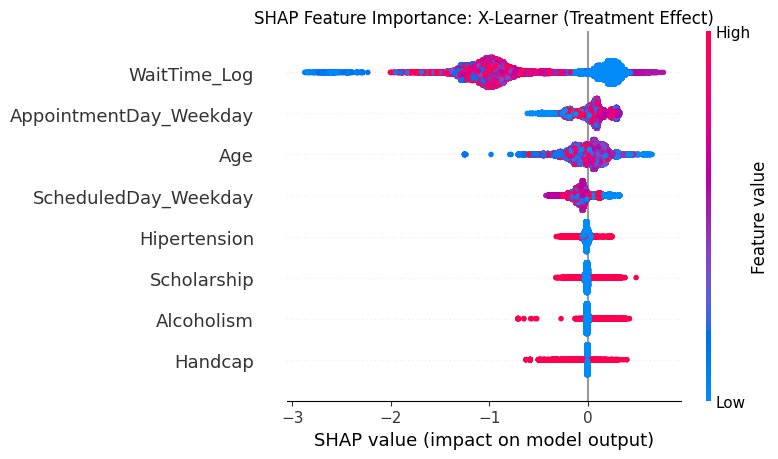

In [55]:
# Calculate CATE contribution for each feature
cate_contribution = np.array(shap_values_treatment) - np.array(shap_values_control)

# Plot SHAP summary for CATE contribution
plot_shap_summary(
    cate_contribution,
    X_resampled_array,
    X_resampled_columns,
    "SHAP Feature Importance: X-Learner (Treatment Effect)"
)

## SHAP Dependence Plot

<Figure size 1000x600 with 0 Axes>

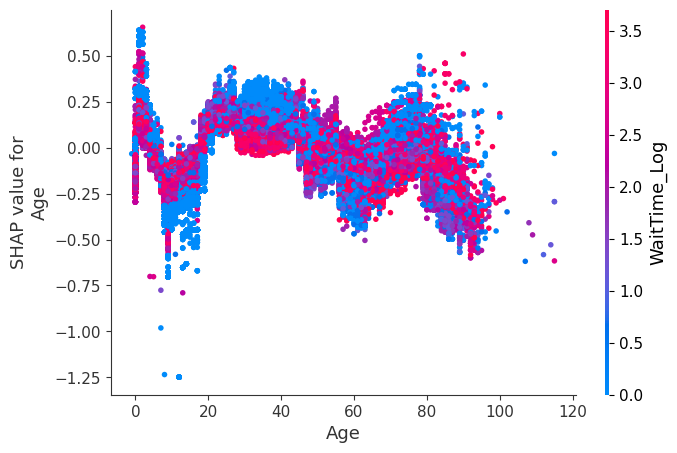

In [56]:
shap_df = pd.DataFrame(cate_contribution, columns=X_resampled_columns)
feature = "Age"

plt.figure(figsize=(10, 6))
shap.dependence_plot(
    feature,
    shap_df.values,  # SHAP values
    X_resampled_array,  # Original feature values
    feature_names=X_resampled_columns,  # Feature column names
    interaction_index="auto"  # Automatically detects best interaction feature
)